**Code Explanation:**
**Path Setup**: Appends the `../code` directory to the Python system path to allow importing custom project modules.

In [12]:
import sys
import os
# Add the sibling 'code' directory to the Python path
sys.path.append(os.path.abspath('../code'))


# Experiment 01 - Basic properties and boundary equilibria

Paper sections reproduced: Section 2, Theorem 2.1, Theorem 2.2, Theorem 2.4, Theorem 2.8.

This notebook uses Monod response functions `f_i(u)=a_i u/(b_i+u)`, which satisfy the assumptions in the paper: `f_i(0)=0` and `f_i'(u)>0`.


**Code Explanation:**
**Imports**: Loads standard scientific libraries (NumPy, SciPy, Matplotlib) and custom functions (`simulate`, `plot_timeseries`, etc.) required for solving the differential equations of the chemostat model.

In [13]:
from utils import monod_inv
from simulation import simulate
from equilibria import P2
from plotting import plot_timeseries

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import brentq
from model import ChemostatModel

plt.rcParams.update({"figure.figsize": (10, 5), "axes.grid": True})

## Experiment 1: positivity, boundedness, dissipativity

Equivalent to Theorem 2.1. Starting from positive initial values, all variables remain non-negative and eventually stay bounded.


**Code Explanation:**
**Theorem 2.1 Demonstration (Boundedness & Dissipativity)**: Simulates the full 4D model using a basic set of parameters. The plot of the total mass ($S + x + y + z$) over time shows that the system is bounded and uniformly dissipative, as theoretically proven in Theorem 2.1.

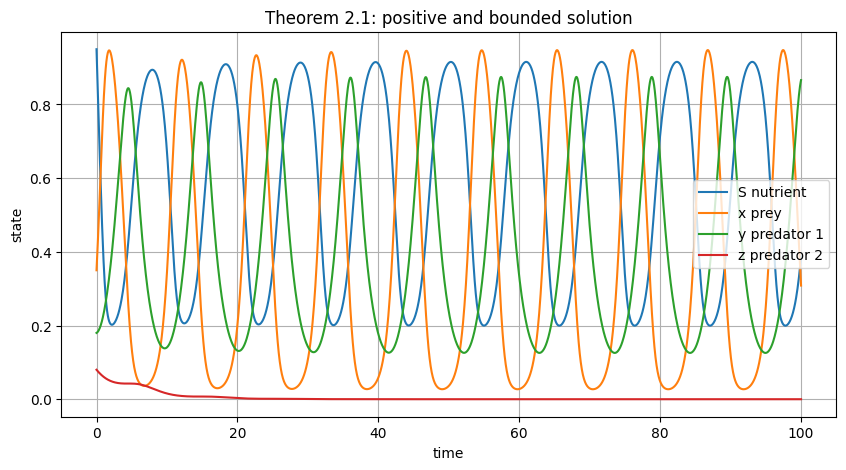

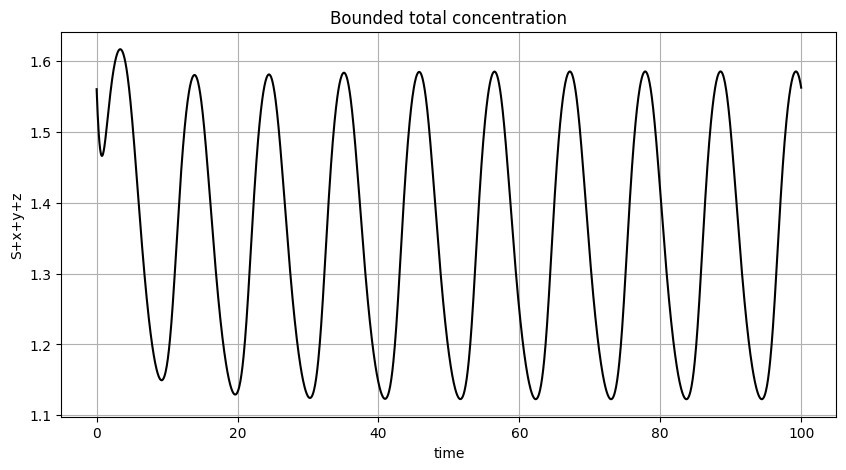

Minimum state value: 2.0157270688572827e-09


In [14]:
p_basic = dict(a1=3.0, b1=0.5, a2=1.6, b2=0.4, a3=0.8, b3=0.5, D1=0.5, D2=0.6, D3=0.5)
sol = simulate(p_basic, U0=(0.95, 0.35, 0.18, 0.08), T=100)
t, S, x, y, z = plot_timeseries(sol, "Theorem 2.1: positive and bounded solution")

plt.figure()
plt.plot(t, S + x + y + z, color="black")
plt.xlabel("time")
plt.ylabel("S+x+y+z")
plt.title("Bounded total concentration")
plt.show()

print("Minimum state value:", np.min([S.min(), x.min(), y.min(), z.min()]))

## Experiment 2: washout equilibrium P0

Equivalent to Theorem 2.2. If `f1(1)<D1`, prey cannot invade even at maximum nutrient. Expected limit: `(1,0,0,0)`.


**Code Explanation:**
**Trivial Equilibrium $P_0$ (Theorem 2.2)**: Uses parameters satisfying the washout condition $f_1(1) < D_1$. The time-series plot confirms that all biological populations ($x, y, z$) wash out, and the nutrient concentration $S$ converges to the input concentration ($S \to 1$).

f1(1)= 0.6666666666666666 D1= 0.8


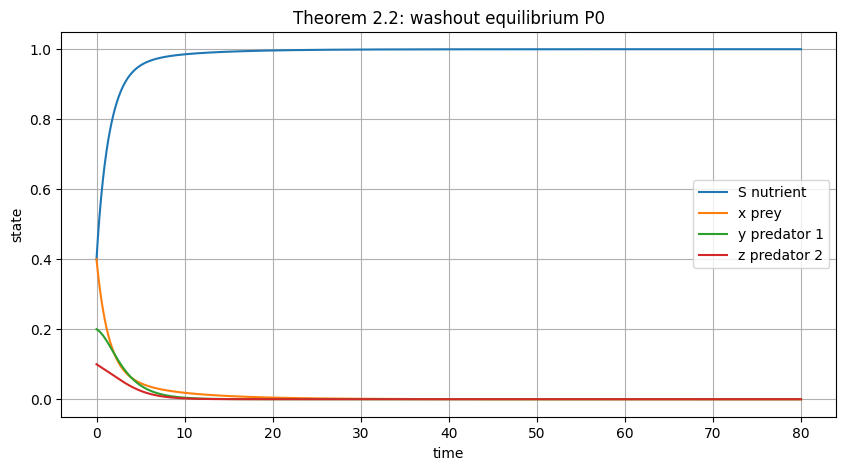

Final state: [9.99998811e-01 1.54533276e-06 3.98099253e-18 1.54420147e-18]


In [15]:
p_P0 = dict(a1=1.0, b1=0.5, a2=1.2, b2=0.4, a3=1.0, b3=0.4, D1=0.8, D2=0.5, D3=0.5)
print("f1(1)=", ChemostatModel(p_P0).f1(1), "D1=", p_P0["D1"])
sol = simulate(p_P0, U0=(0.4, 0.4, 0.2, 0.1), T=80)
plot_timeseries(sol, "Theorem 2.2: washout equilibrium P0")
print("Final state:", sol.y[:, -1])

## Experiment 3: boundary equilibrium P1

Equivalent to Theorem 2.4 and Theorem 3.1. Here prey survives, while both predators are washed out. We choose parameters so that `f1(1)>D1` and `f2(x1)<D2`.


**Code Explanation:**
**Boundary Equilibrium $P_1$ (Theorems 2.4 & 2.5)**: Simulates the system where the invasion condition for predator 1 fails ($f_2(x_1) < D_2$). The plots demonstrate that the prey $x$ survives alongside the nutrient, but the predators $y$ and $z$ are washed out. The phase portrait in the $S$-$x$ plane shows convergence to $P_1(S_1, x_1, 0, 0)$.

P1 = (0.21538461538461537, 1.120879120879121, 0, 0)
invasion check f2(x1)-D2 = -0.03508474576271192


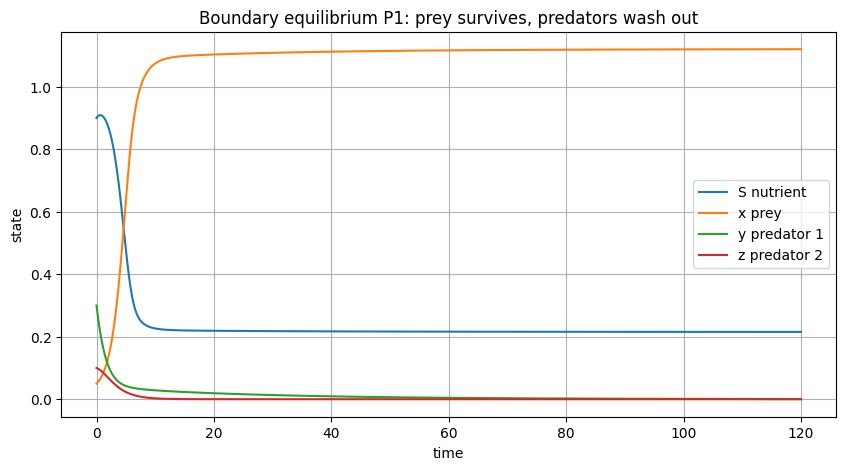

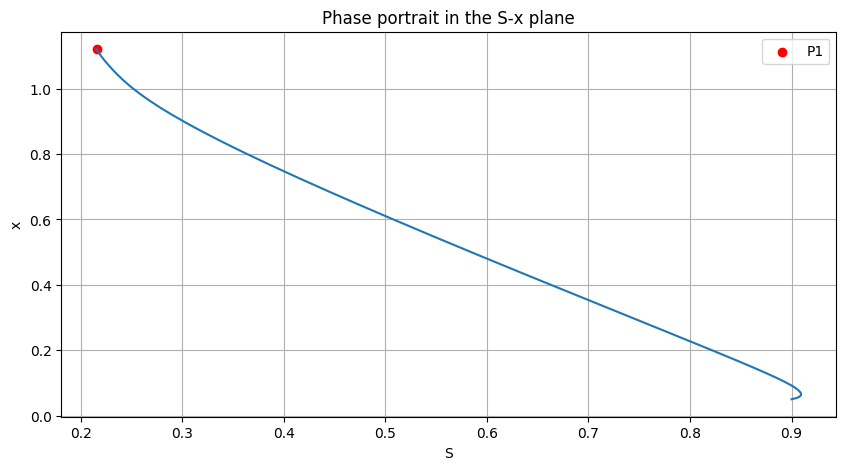

In [16]:
p_P1 = dict(a1=2.0, b1=0.4, a2=0.6, b2=0.5, a3=1.0, b3=0.4, D1=0.7, D2=0.45, D3=0.5)
S1 = monod_inv(p_P1["D1"], p_P1["a1"], p_P1["b1"])
x1 = (1 - S1) / p_P1["D1"]
print("P1 =", (S1, x1, 0, 0))
print("invasion check f2(x1)-D2 =", ChemostatModel(p_P1).f2(x1) - p_P1["D2"])

sol = simulate(p_P1, U0=(0.9, 0.05, 0.3, 0.1), T=120)
plot_timeseries(sol, "Boundary equilibrium P1: prey survives, predators wash out")

t = np.linspace(0, 120, 2000)
S, x, y, z = sol.sol(t)
plt.figure()
plt.plot(S, x)
plt.scatter([S1], [x1], color="red", label="P1")
plt.xlabel("S")
plt.ylabel("x")
plt.title("Phase portrait in the S-x plane")
plt.legend()
plt.show()

## Experiment 4: boundary equilibrium P2

Equivalent to Theorem 2.8 and Theorem 3.2. Nutrient, prey, and predator 1 coexist; predator 2 is washed out. We choose parameters so that `f3(y2)<D3`.


**Code Explanation:**
**Boundary Equilibrium $P_2$ (Theorems 2.8 & 2.9)**: Uses parameters where prey and predator 1 can survive, but predator 2 cannot ($f_3(y_2) < D_3$). The timeseries and the 3D phase portrait in $S$-$x$-$y$ space show the trajectory spiraling and converging to the boundary equilibrium $P_2(S_2, x_2, y_2, 0)$.

P2 = (np.float64(0.6056116265125947), np.float64(0.24), np.float64(0.45731395581234413), 0)
invasion check f3(y2)-D3 = -0.11783575552345682


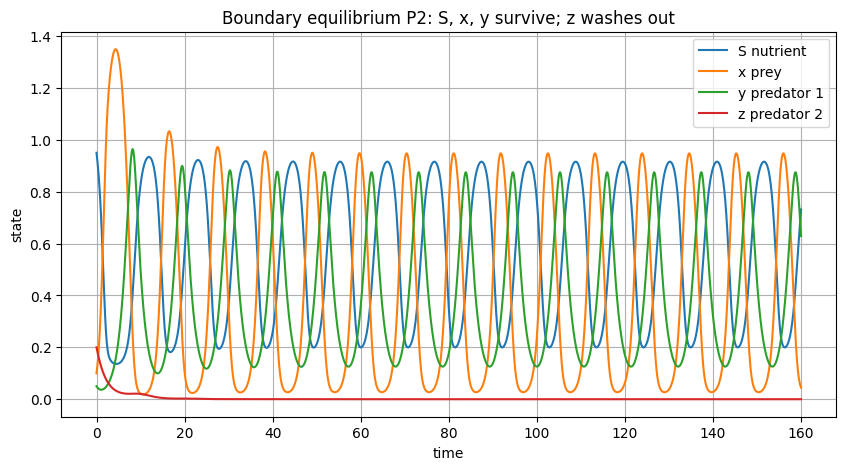

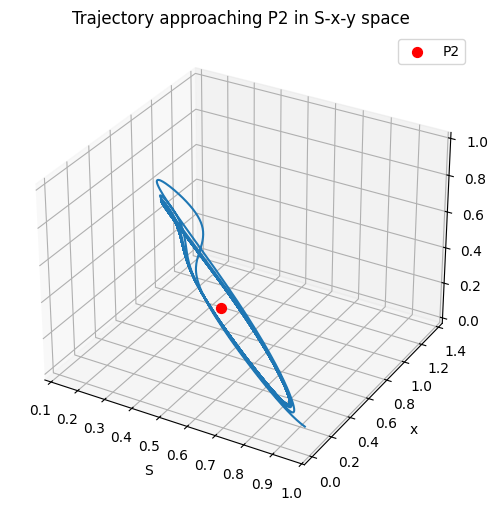

In [17]:
p_P2 = dict(a1=3.0, b1=0.5, a2=1.6, b2=0.4, a3=0.8, b3=0.5, D1=0.5, D2=0.6, D3=0.5)
# x2 computed in P2
S2, x2, y2, _ = P2(p_P2)
print("P2 =", (S2, x2, y2, 0))
print("invasion check f3(y2)-D3 =", ChemostatModel(p_P2).f3(y2) - p_P2["D3"])

sol = simulate(p_P2, U0=(0.95, 0.1, 0.05, 0.2), T=160)
plot_timeseries(sol, "Boundary equilibrium P2: S, x, y survive; z washes out")

t = np.linspace(0, 160, 2500)
S, x, y, z = sol.sol(t)
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot(S, x, y)
ax.scatter([S2], [x2], [y2], color="red", s=50, label="P2")
ax.set_xlabel("S")
ax.set_ylabel("x")
ax.set_zlabel("y")
ax.set_title("Trajectory approaching P2 in S-x-y space")
ax.legend()
plt.show()